In [18]:
# ============================================================
# ✅ IMPORTS
# ============================================================
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [19]:
# ============================================================
# ✅ PATH SETUP
# ============================================================
TRAIN_DIR = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/train"
OUTPUT_DIR = "/kaggle/working/resnet50_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# ✅ DATA GENERATORS
# ============================================================
batch_size = 16
target_size = (256, 256)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='sparse',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='sparse',
    subset='validation',
    shuffle=False,
    seed=42
)

num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())

Found 4002 images belonging to 4 classes.
Found 998 images belonging to 4 classes.


In [23]:
# ============================================================
# ✅ MODEL: ResNet50 + GAP
# ============================================================
base_model = ResNet50(weights='imagenet', include_top=False,
                      input_shape=(256, 256, 3))
base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
# ============================================================
# ✅ CALLBACKS
# ============================================================
early_stop = EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.5,
                              patience=5,
                              min_lr=1e-6)

# ============================================================
# ✅ TRAINING (100 EPOCHS)
# ============================================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1771740302.952600     254 service.cc:152] XLA service 0x79ced0004f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771740302.952641     254 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771740302.952645     254 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771740308.571433     254 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-22 06:05:17.201416: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 06:05:17.354098: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1771740331.022576     254 device_co

 98/251 ━━━━━━━━━━━━━━━━━━━━ 48s 320ms/step - accuracy: 0.6645 - loss: 1.4347

2026-02-22 06:06:11.819327: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 06:06:11.965466: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


251/251 ━━━━━━━━━━━━━━━━━━━━ 180s 488ms/step - accuracy: 0.7565 - loss: 1.1794 - val_accuracy: 0.2144 - val_loss: 2.5746 - learning_rate: 1.0000e-04
Epoch 2/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 86s 341ms/step - accuracy: 0.9206 - loss: 0.6739 - val_accuracy: 0.2154 - val_loss: 4.6278 - learning_rate: 1.0000e-04
Epoch 3/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 86s 341ms/step - accuracy: 0.9442 - loss: 0.6003 - val_accuracy: 0.3958 - val_loss: 4.4395 - learning_rate: 1.0000e-04
Epoch 4/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 87s 346ms/step - accuracy: 0.9593 - loss: 0.5535 - val_accuracy: 0.6082 - val_loss: 2.5270 - learning_rate: 1.0000e-04
Epoch 5/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 87s 346ms/step - accuracy: 0.9619 - loss: 0.5466 - val_accuracy: 0.8307 - val_loss: 1.1396 - learning_rate: 1.0000e-04
Epoch 6/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 86s 344ms/step - accuracy: 0.9548 - loss: 0.5673 - val_accuracy: 0.8928 - val_loss: 1.3966 - learning_rate: 1.0000e-04
Epoch 7/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 349ms/

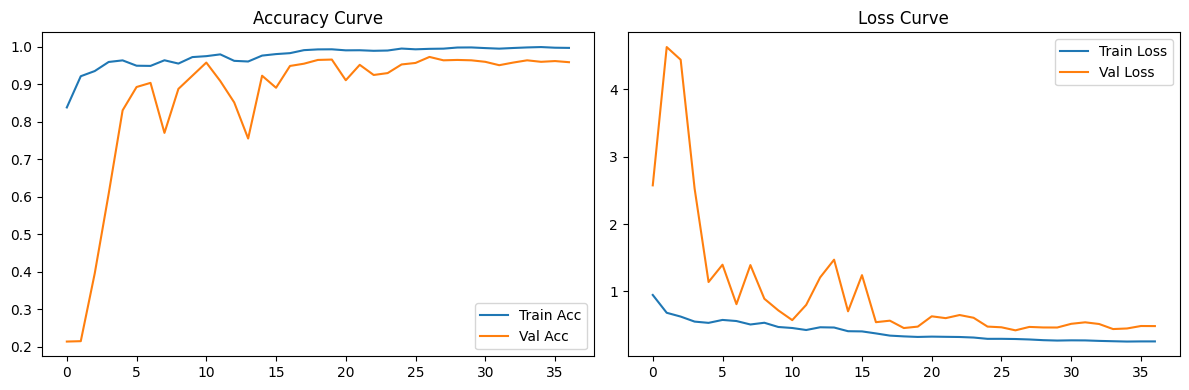

✅ Training curves saved successfully.


In [31]:
# ============================================================
# ✅ TRAINING CURVES
# ============================================================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

curve_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.tight_layout()
plt.savefig(curve_path)
plt.show()

print("✅ Training curves saved successfully.")

In [34]:
# ============================================================
# ✅ EVALUATION
# ============================================================
val_generator.reset()
pred_probs = model.predict(val_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_generator.classes

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

print(f"\n✅ Accuracy:  {acc*100:.2f}%")
print(f"✅ Precision: {prec*100:.2f}%")
print(f"✅ Recall:    {rec*100:.2f}%")
print(f"✅ F1-Score:  {f1*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 262ms/step

Classification Report:

              precision    recall  f1-score   support

      glioma       0.99      1.00      0.99       229
  meningioma       0.98      0.92      0.95       265
    no_tumor       0.92      1.00      0.96       213
   pituitary       1.00      0.98      0.99       291

    accuracy                           0.97       998
   macro avg       0.97      0.98      0.97       998
weighted avg       0.98      0.97      0.97       998


✅ Accuracy:  97.39%
✅ Precision: 97.23%
✅ Recall:    97.59%
✅ F1-Score:  97.34%


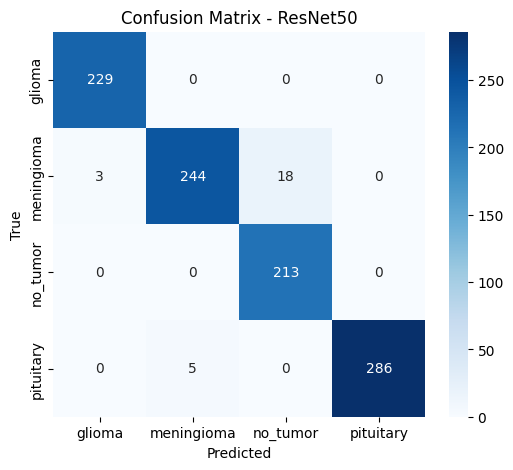

In [35]:
# ============================================================
# ✅ CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - ResNet50")

cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path)
plt.show()

In [36]:
# ============================================================
# ✅ SAVE METRICS
# ============================================================
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)

metrics_df = pd.DataFrame(report).transpose()
metrics_path = os.path.join(OUTPUT_DIR, "metrics.csv")
metrics_df.to_csv(metrics_path)

# Save confusion matrix array
np.save(os.path.join(OUTPUT_DIR, "confusion_matrix.npy"), cm)

# ============================================================
# ✅ ZIP ALL RESULTS
# ============================================================
zip_path = "/kaggle/working/resnet50_results.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in os.listdir(OUTPUT_DIR):
        zipf.write(os.path.join(OUTPUT_DIR, file), file)

print(f"\n📦 Results saved to: {zip_path}")


📦 Results saved to: /kaggle/working/resnet50_results.zip
